#### Data Availability Check

In [2]:
from pathlib import Path
plantvillage_path = Path("../data/raw/plantvillage")
train_split = plantvillage_path/"splits/color_train.txt"
test_split = plantvillage_path/"splits/color_test.txt"
with open(train_split) as f:
    train_paths = [line.strip() for line in f if line.strip()]
with open(test_split) as f:
    test_paths = [line.strip() for line in f if line.strip()]

print("Train references:",len(train_paths))
print("Test references:", len(test_paths))

Train references: 43596
Test references: 10709


In [3]:
missing_train = [
    path for path in train_paths
    if not (plantvillage_path/path).exists()
]

missing_test = [
    path for path in test_paths
    if not (plantvillage_path/path).exists()
]

print("Missing train images: ",len(missing_train))
print("Missing test images: ", len(missing_test))

Missing train images:  0
Missing test images:  0


In [4]:
# Overlap test 
train_set = set(train_paths)
test_set = set(test_paths)

overlap = train_set.intersection(test_set)

print("Train images:",len(train_set))
print("Test images:", len(test_set))
print("Overlap images:",len(overlap))

Train images: 43596
Test images: 10709
Overlap images: 0


In [5]:
#Verify the label 
def extract_label(path):
    return Path(path).parent.name

In [6]:
train_labels = [extract_label(path) for path in train_paths]
test_labels = [extract_label(path) for path in test_paths]

print(train_labels[:10])

['Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy', 'Raspberry___healthy']


In [7]:
print("Train classes:", len(set(train_labels)))
print("Test classes :", len(set(test_labels)))

Train classes: 38
Test classes : 38


In [8]:
train_classes = set(train_labels)
test_classes = set(test_labels)

print("Train only:", train_classes - test_classes)
print("Test only :", test_classes - train_classes)

Train only: set()
Test only : set()


In [9]:
from collections import Counter

train_distribution = Counter(train_labels)
test_distribution = Counter(test_labels)

for label, count in train_distribution.most_common():
    print(f"{label:50s} {count}")

Orange___Haunglongbing_(Citrus_greening)           4527
Tomato___Tomato_Yellow_Leaf_Curl_Virus             4257
Soybean___healthy                                  4117
Peach___Bacterial_spot                             1755
Tomato___Bacterial_spot                            1691
Tomato___Late_blight                               1534
Squash___Powdery_mildew                            1457
Tomato___Septoria_leaf_spot                        1434
Apple___healthy                                    1359
Tomato___Spider_mites Two-spotted_spider_mite      1356
Tomato___healthy                                   1261
Pepper,_bell___healthy                             1195
Blueberry___healthy                                1178
Tomato___Target_Spot                               1116
Grape___Esca_(Black_Measles)                       1099
Grape___Black_rot                                  1012
Corn_(maize)___Common_rust_                        975
Corn_(maize)___healthy                           

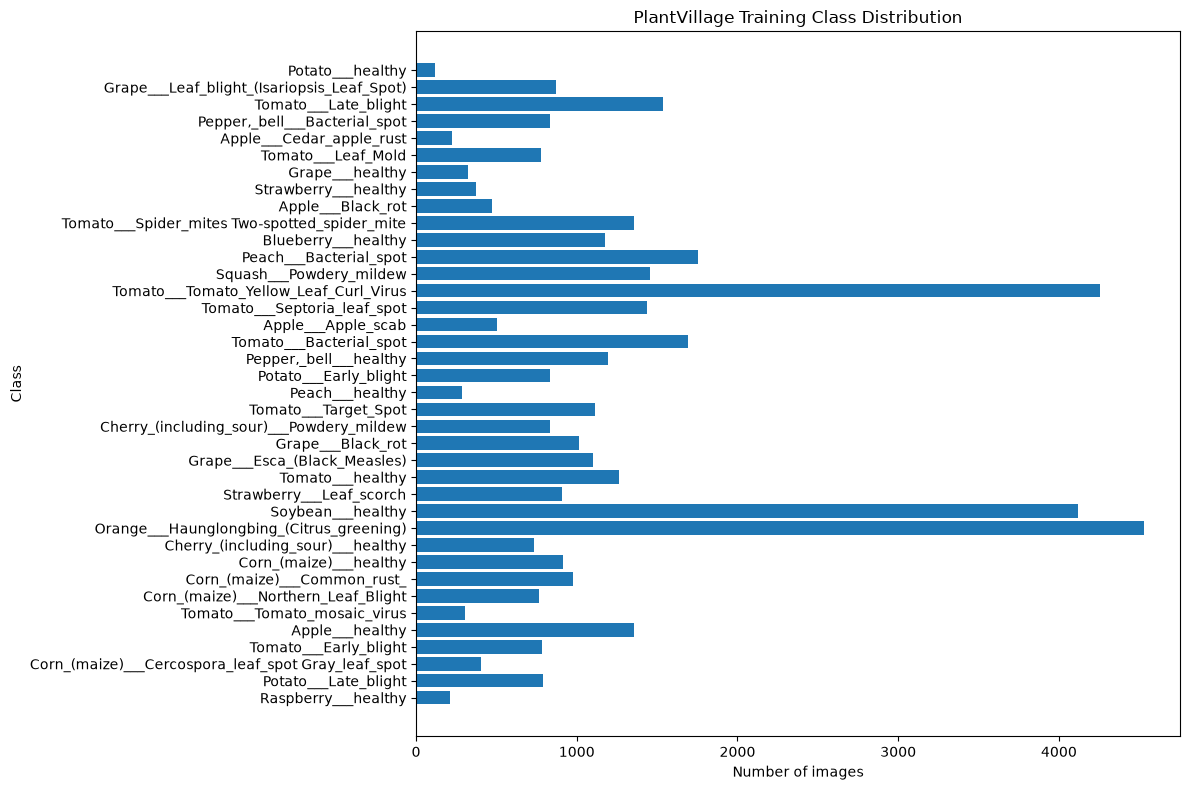

In [10]:
import matplotlib.pyplot as plt

labels = list(train_distribution.keys())
counts = list(train_distribution.values())

plt.figure(figsize=(12, 8))
plt.barh(labels, counts)
plt.xlabel("Number of images")
plt.ylabel("Class")
plt.title("PlantVillage Training Class Distribution")
plt.tight_layout()
plt.show()

In [ ]:
# Bad Image Count
from PIL import Image
bad_images = []
for path in train_paths + test_paths:
    image_path = plantvillage_path/path
    try:
        with Image.open(image_path) as img:
            img.verify()
    except Exception:
        bad_images.append(path)
print("Bad Images: ", len(bad_images))

Bad Images:  0


In [12]:
# Image Dimension
from collections import Counter
sizes = Counter()
modes = Counter()

for path in train_paths:
    image_path = plantvillage_path/path
    with Image.open(image_path) as img:
        sizes[img.size] +=1
        modes[img.mode] +=1

print("Image Sizes:")
for size, count in sizes.most_common():
    print(size,count)

print("\n Image Modes")
for mode, count in modes.most_common():
    print(mode,count)

Image Sizes:
(256, 256) 43596

 Image Modes
RGB 43596


In [13]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_samples(paths, n=9):
    samples = random.sample(paths,n)
    fig,axes = plt.subplots(3,3, figsize=(12,12))
    for ax, path in zip(axes.flat,samples):
        image_path = plantvillage_path/path
        image = Image.open(image_path)
        ax.imshow(image)
        ax.set_title(Path(path).parent.name,fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

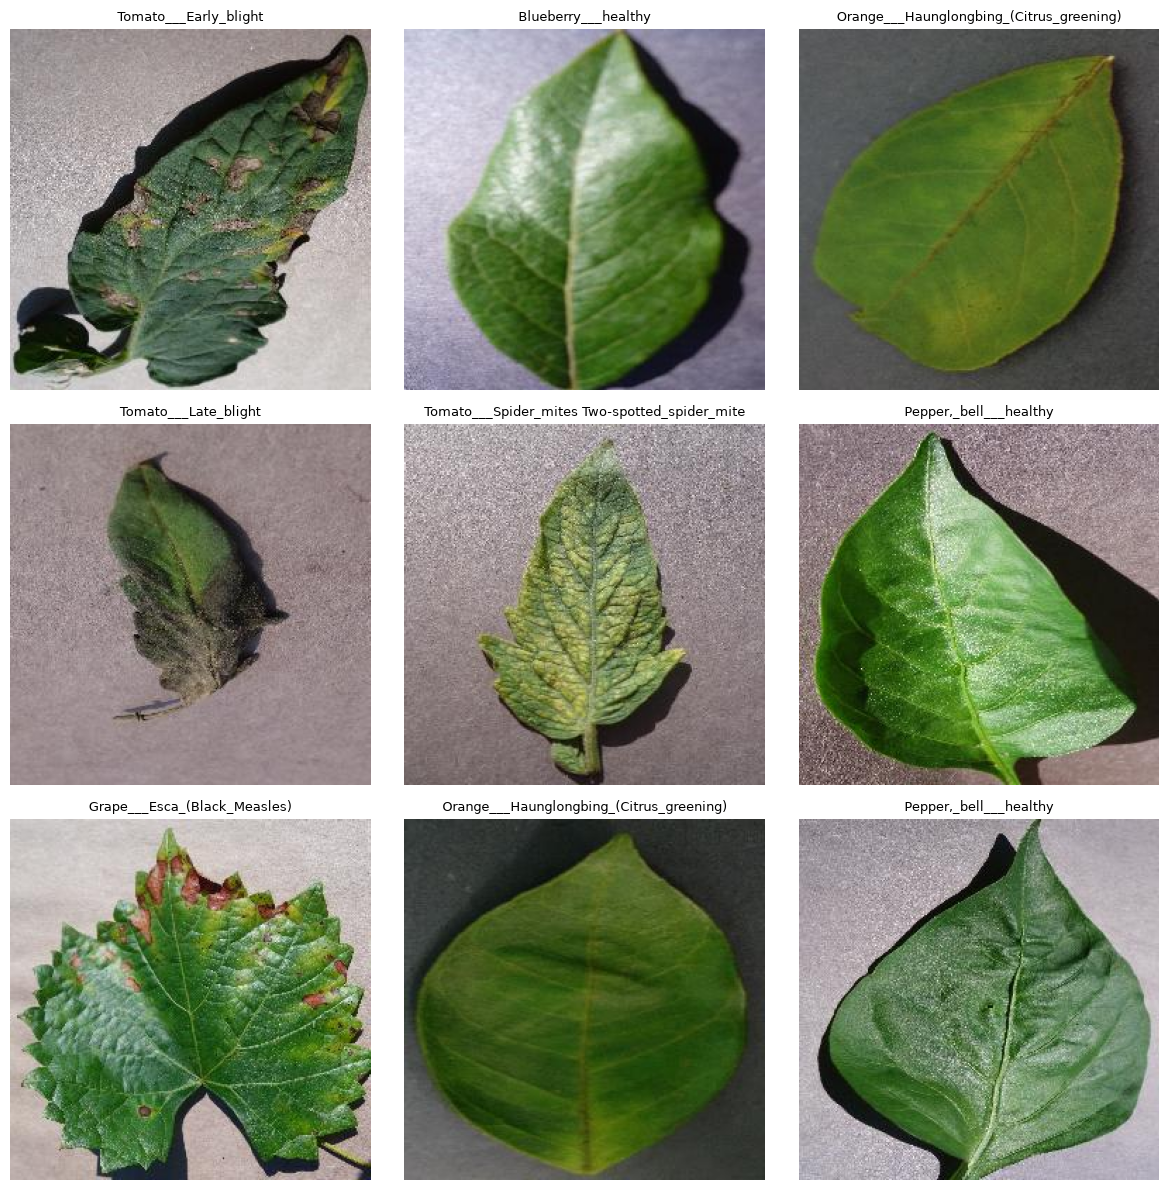

In [14]:
show_samples(train_paths)